In [1]:
import os
import math
import json
import random
import pandas as pd
import numpy as np
import scipy as sp
import pylab as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


import jupyter_black

jupyter_black.load()

%load_ext autoreload
%autoreload 2
import src.count_utils as utils

In [2]:
VERSION = "research-article_aimrd_f"
BASELINE = "baseline_2026-01-23"
RESULTS_PATH = os.path.join("../../data/results/", BASELINE, VERSION)
CUTOFF_VERSION = "subsubopt"
sections = ["abstract", "introduction", "methods", "results", "discussion", "full"]
colors = dict(zip(sections, sns.color_palette("colorblind", len(sections))))
# change full color to make it less similar to introduction
colors["full"] = (0.541, 0.365, 0.224)

In [3]:
sec = "full"

country_df = utils.get_country_frequency(RESULTS_PATH, sec, CUTOFF_VERSION)
p = country_df["projection"]
q = country_df["frequency"]
totals = country_df["paper_counts"]
reg_se = country_df["regression se"]
country_df["regression se (ds)"] = list(
    map(utils.se, p, q, totals, ["regression"] * len(p), reg_se)
)

loading country freqs


In [4]:
country_alt_names = {
    "United States of America": "USA",
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "Korea, Republic of": "South Korea",
    "Iran, Islamic Republic of": "Iran",
    "Türkiye": "Turkey",
    "english": "English speakers",
    "non-english": "non-English speakers",
}

In [5]:
df = country_df
df["country"] = [
    country_alt_names[c] if c in country_alt_names.keys() else c for c in df["cutoff"]
]
df = df.drop("cutoff", axis=1)
english_countries = ["USA", "UK", "Canada", "Australia", "English speakers"]
df["group"] = ["NES" if c in english_countries else "NNES" for c in df["country"]]
df

,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds),country,group
0,2018,0.658520,0.648619,0.009901,0.028178,0.013962,16366.0,0.040029,China,NNES
1,2018,0.909262,0.907840,0.001423,0.015437,0.002659,15384.0,0.037924,USA,NES
2,2018,0.879457,0.877587,0.001870,0.015278,0.003497,6478.0,0.043398,UK,NES
3,2018,0.643892,0.637906,0.005986,0.016531,0.015215,5385.0,0.045083,Japan,NNES
4,2018,0.880241,0.878379,0.001862,0.015310,0.002691,4483.0,0.045435,Germany,NNES
...,...,...,...,...,...,...,...,...,...,...
171,2025,0.937759,0.712241,0.225519,0.783706,0.028413,963.0,0.034468,Iran,NNES
172,2025,0.897353,0.691058,0.206295,0.667746,0.045326,1850.0,0.053831,Turkey,NNES
173,2025,0.936937,0.878593,0.058344,0.480567,0.007798,887.0,0.075050,Poland,NNES
174,2025,0.962530,0.940148,0.022383,0.373963,0.002683,48358.0,0.031552,English speakers,NES


In [6]:
df_comp = df[df["time"] == 2022][["frequency", "country", "group"]]
df_comp["usage"] = list(df[df["time"] == 2025]["usage estimate"])
df_comp["se"] = list(df[df["time"] == 2025]["regression se (ds)"])
df_comp = df_comp[
    df_comp["country"].apply(
        lambda x: not x in ["English speakers", "non-English speakers"]
    )
]
df_comp

,frequency,country,group,usage,se
88,0.745826,China,NNES,0.821765,0.019926
89,0.930183,USA,NES,0.386732,0.050726
90,0.910011,UK,NES,0.280935,0.065124
91,0.676164,Japan,NNES,0.550753,0.036541
92,0.900993,Germany,NNES,0.526702,0.035276
93,0.853543,Italy,NNES,0.611601,0.046105
94,0.916909,Canada,NES,0.464041,0.137614
95,0.861871,Netherlands,NNES,0.490595,0.050276
96,0.878169,France,NNES,0.329718,0.108606
97,0.907204,Australia,NES,0.309464,0.105603


In [7]:
df_comp_filt = df_comp[df_comp["se"] < 0.07]
df_comp_filt

,frequency,country,group,usage,se
88,0.745826,China,NNES,0.821765,0.019926
89,0.930183,USA,NES,0.386732,0.050726
90,0.910011,UK,NES,0.280935,0.065124
91,0.676164,Japan,NNES,0.550753,0.036541
92,0.900993,Germany,NNES,0.526702,0.035276
93,0.853543,Italy,NNES,0.611601,0.046105
95,0.861871,Netherlands,NNES,0.490595,0.050276
98,0.720944,South Korea,NNES,0.849940,0.020989
99,0.859853,Spain,NNES,0.703154,0.067314
100,0.823967,Brazil,NNES,0.626389,0.037441


In [8]:
plt.style.use("../../src/mpl_style_2.txt")
mpl.rcParams["font.sans-serif"] = ["Arial", "Liberation Sans", "DejaVu Sans"]
plt.rcParams.update(
    {
        "font.size": 5,  # base size
        "axes.labelsize": 5,  # x/y labels
        "axes.titlesize": 6,  # subplot titles
        "xtick.labelsize": 4,
        "ytick.labelsize": 4,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
    }
)

In [9]:
country_colors = {"NNES": "tab:green", "NES": "tab:purple"}

In [24]:
annotation_alignment = {
    "South Korea": {"ha": "right", "va": "bottom"},
    "Iran": {"ha": "right", "va": "bottom"},
    "China": {"ha": "right", "va": "top"},
    "France": {"ha": "right", "va": "top"},
    "Turkey": {"ha": "left", "va": "bottom"},
    "Brazil": {"ha": "right", "va": "top"},
    "India": {"ha": "right", "va": "bottom"},
    "Germany": {"ha": "left", "va": "top"},
    "USA": {"ha": "left", "va": "bottom"},
    "UK": {"ha": "left", "va": "top"},
    "Canada": {"ha": "left", "va": "bottom"},
    "Japan": {"ha": "left", "va": "bottom"},
    "Italy": {"ha": "left", "va": "top"},
    "Netherlands": {"ha": "right", "va": "top"},
    "Sweden": {"ha": "left", "va": "bottom"},
    "Switzerland": {"ha": "left", "va": "bottom"},
    "Spain": {"ha": "left", "va": "bottom"},
    "Taiwan": {"ha": "left", "va": "bottom"},
}

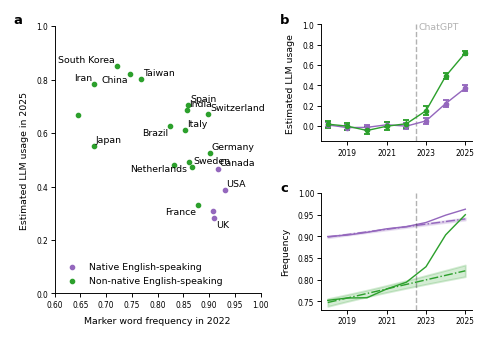

In [11]:
# Version 1

fig = plt.figure(figsize=(3.5, 2.4), constrained_layout=True)

# Main layout:
# [large] [2x1 block]
gs = GridSpec(
    nrows=1,
    ncols=2,
    width_ratios=[1, 1],
    figure=fig,
    # left=0.06,
    # right=0.99,
    # bottom=0.18,
    # top=0.95,
    # wspace=0.1,
)
# Large panel 1
ax1 = fig.add_subplot(gs[0])

# Middle 2x1 block
gs_middle = GridSpecFromSubplotSpec(
    2,
    1,
    subplot_spec=gs[1],
    wspace=0.08,
    hspace=0.15,
)
ax2 = fig.add_subplot(gs_middle[0, 0])
ax3 = fig.add_subplot(gs_middle[1, 0])

#### panel a
for group, d in df_comp.groupby("group"):
    ax1.scatter(d["frequency"], d["usage"], label=group, c=country_colors[group])

for _, row in df_comp.iterrows():
    c = row["country"]
    if c in annotation_alignment.keys():
        x_offset = 1 if annotation_alignment[c]["ha"] == "left" else -1
        y_offset = 1 if annotation_alignment[c]["va"] == "bottom" else -1
        ax1.annotate(
            c,
            xy=(row["frequency"], row["usage"]),
            xytext=(x_offset, y_offset),
            textcoords="offset points",
            ha=annotation_alignment[c]["ha"],
            va=annotation_alignment[c]["va"],
        )


for group, name in zip(["NES", "NNES"], ["English speakers", "non-English speakers"]):
    sub = df[df["country"] == name].sort_values("time")
    #### panel b
    ax2.errorbar(
        sub["time"],
        sub["usage estimate"],
        yerr=sub["regression se (ds)"],
        color=country_colors[group],
        marker="o",
        linestyle="-",
        capsize=1.4,
        markersize=2,
        clip_on=True,
        label=name,
    )

    #### panel c
    ax3.plot(
        sub["time"],
        sub["frequency"],
        color=country_colors[group],
        label="($q$)",
    )

    ax3.plot(
        sub["time"],
        sub["projection"],
        # yerr=sub["regression se"],
        color=country_colors[group],
        linestyle="-.",
        label="($\\hat{p}_{human}$)",
    )

    ax3.fill_between(
        sub["time"],
        sub["projection"] - sub["regression se"],
        sub["projection"] + sub["regression se"],
        alpha=0.2,
        color=country_colors[group],
    )

for ax in [ax2, ax3]:
    ax.axvline(x=2022.5, linestyle="--", color="black", alpha=0.3)
ax2.text(
    x=2022.6,
    y=0.95,
    s="ChatGPT",
    color="black",
    alpha=0.3,
    horizontalalignment="left",
)
ax1.set_xlim([0.6, 1.0])
ax1.set_ylim([0, 1])
ax2.set_ylim([-0.15, 1])
ax3.set_ylim([0.73, 1])

for ax in [ax2, ax3]:
    ax.set_xticks(range(2019, 2026, 2))
    ax.set_xticklabels(range(2019, 2026, 2))

ax1.set_xlabel("Marker word frequency in 2022")
ax1.set_ylabel("Estimated LLM usage in 2025")
ax2.set_ylabel("Estimated LLM usage")
ax3.set_ylabel("Frequency")

handles, labels = ax1.get_legend_handles_labels()
label_map = {
    "NES": "Native English-speaking",
    "NNES": "Non-native English-speaking",
}

ax1.legend(handles, [label_map.get(label, label) for label in labels], loc="lower left")

for ax, letter in zip([ax1, ax2, ax3], ["a", "b", "c"]):
    if letter == "a":
        x = -0.2
        y = 1.05
    else:
        x = -0.27
        y = 1.1
    ax.text(
        x,
        y,
        letter,
        transform=ax.transAxes,
        fontsize=7,
        fontweight="bold",
        va="top",
    )

# fig.savefig(
#    "countries_v1.pdf",
#    format="pdf",
# bbox_inches="tight",
# )

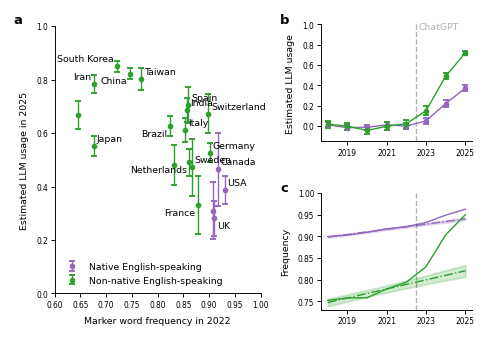

In [12]:
# version 2 with errorbars

fig = plt.figure(figsize=(3.5, 2.4), constrained_layout=True)

# Main layout:
# [large] [2x1 block]
gs = GridSpec(
    nrows=1,
    ncols=2,
    width_ratios=[1, 1],
    figure=fig,
    # left=0.06,
    # right=0.99,
    # bottom=0.18,
    # top=0.95,
    # wspace=0.1,
)
# Large panel 1
ax1 = fig.add_subplot(gs[0])

# Middle 2x1 block
gs_middle = GridSpecFromSubplotSpec(
    2,
    1,
    subplot_spec=gs[1],
    wspace=0.08,
    hspace=0.15,
)
ax2 = fig.add_subplot(gs_middle[0, 0])
ax3 = fig.add_subplot(gs_middle[1, 0])

#### panel a
for group, d in df_comp.groupby("group"):
    ax1.errorbar(
        d["frequency"],
        d["usage"],
        yerr=d["se"],  # vertical error bars
        fmt="o",  # marker only
        linestyle="none",  # no connecting lines
        color=country_colors[group],
        ecolor=country_colors[group],
        capsize=1.4,
        markersize=2,
        label=group,
    )

for _, row in df_comp.iterrows():
    c = row["country"]
    if c in annotation_alignment.keys():
        x_offset = 1.5 if annotation_alignment[c]["ha"] == "left" else -1.5
        y_offset = 1.5 if annotation_alignment[c]["va"] == "bottom" else -1.5
        ax1.annotate(
            c,
            xy=(row["frequency"], row["usage"]),
            xytext=(x_offset, y_offset),
            textcoords="offset points",
            ha=annotation_alignment[c]["ha"],
            va=annotation_alignment[c]["va"],
        )


for group, name in zip(["NES", "NNES"], ["English speakers", "non-English speakers"]):
    sub = df[df["country"] == name].sort_values("time")
    #### panel b
    ax2.errorbar(
        sub["time"],
        sub["usage estimate"],
        yerr=sub["regression se (ds)"],
        color=country_colors[group],
        marker="o",
        linestyle="-",
        capsize=1.4,
        markersize=2,
        clip_on=True,
        label=name,
    )

    #### panel c
    ax3.plot(
        sub["time"],
        sub["frequency"],
        color=country_colors[group],
        label="($q$)",
    )

    ax3.plot(
        sub["time"],
        sub["projection"],
        # yerr=sub["regression se"],
        color=country_colors[group],
        linestyle="-.",
        label="($\\hat{p}_{human}$)",
    )

    ax3.fill_between(
        sub["time"],
        sub["projection"] - sub["regression se"],
        sub["projection"] + sub["regression se"],
        alpha=0.2,
        color=country_colors[group],
    )

for ax in [ax2, ax3]:
    ax.axvline(x=2022.5, linestyle="--", color="black", alpha=0.3)
ax2.text(
    x=2022.6,
    y=0.95,
    s="ChatGPT",
    color="black",
    alpha=0.3,
    horizontalalignment="left",
)
ax1.set_xlim([0.6, 1.0])
ax1.set_ylim([0, 1])
ax2.set_ylim([-0.15, 1])
ax3.set_ylim([0.73, 1])

for ax in [ax2, ax3]:
    ax.set_xticks(range(2019, 2026, 2))
    ax.set_xticklabels(range(2019, 2026, 2))

ax1.set_xlabel("Marker word frequency in 2022")
ax1.set_ylabel("Estimated LLM usage in 2025")
ax2.set_ylabel("Estimated LLM usage")
ax3.set_ylabel("Frequency")

handles, labels = ax1.get_legend_handles_labels()
label_map = {
    "NES": "Native English-speaking",
    "NNES": "Non-native English-speaking",
}

ax1.legend(handles, [label_map.get(label, label) for label in labels], loc="lower left")

for ax, letter in zip([ax1, ax2, ax3], ["a", "b", "c"]):
    if letter == "a":
        x = -0.2
        y = 1.05
    else:
        x = -0.27
        y = 1.1
    ax.text(
        x,
        y,
        letter,
        transform=ax.transAxes,
        fontsize=7,
        fontweight="bold",
        va="top",
    )

fig.savefig(
    "countries_v2.pdf",
    format="pdf",
    # bbox_inches="tight",
)

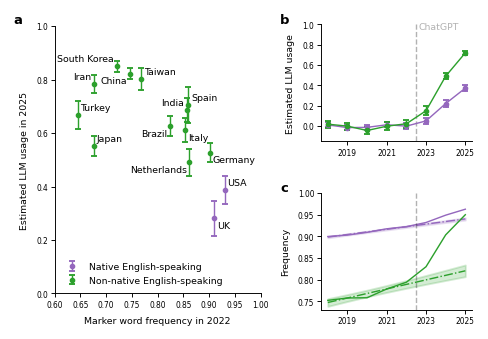

In [25]:
# version 3 only uncertainty < 0.07

fig = plt.figure(figsize=(3.5, 2.4), constrained_layout=True)

# Main layout:
# [large] [2x1 block]
gs = GridSpec(
    nrows=1,
    ncols=2,
    width_ratios=[1, 1],
    figure=fig,
    # left=0.06,
    # right=0.99,
    # bottom=0.18,
    # top=0.95,
    # wspace=0.1,
)
# Large panel 1
ax1 = fig.add_subplot(gs[0])

# Middle 2x1 block
gs_middle = GridSpecFromSubplotSpec(
    2,
    1,
    subplot_spec=gs[1],
    wspace=0.08,
    hspace=0.15,
)
ax2 = fig.add_subplot(gs_middle[0, 0])
ax3 = fig.add_subplot(gs_middle[1, 0])

#### panel a
for group, d in df_comp_filt.groupby("group"):
    ax1.errorbar(
        d["frequency"],
        d["usage"],
        yerr=d["se"],  # vertical error bars
        fmt="o",  # marker only
        linestyle="none",  # no connecting lines
        color=country_colors[group],
        ecolor=country_colors[group],
        capsize=1.4,
        markersize=2,
        label=group,
    )

for _, row in df_comp_filt.iterrows():
    c = row["country"]
    if c in annotation_alignment.keys():
        x_offset = 1.5 if annotation_alignment[c]["ha"] == "left" else -1.5
        y_offset = 1.5 if annotation_alignment[c]["va"] == "bottom" else -1.5
        ax1.annotate(
            c,
            xy=(row["frequency"], row["usage"]),
            xytext=(x_offset, y_offset),
            textcoords="offset points",
            ha=annotation_alignment[c]["ha"],
            va=annotation_alignment[c]["va"],
        )


for group, name in zip(["NES", "NNES"], ["English speakers", "non-English speakers"]):
    sub = df[df["country"] == name].sort_values("time")
    #### panel b
    ax2.errorbar(
        sub["time"],
        sub["usage estimate"],
        yerr=sub["regression se (ds)"],
        color=country_colors[group],
        marker="o",
        linestyle="-",
        capsize=1.4,
        markersize=2,
        clip_on=True,
        label=name,
    )

    #### panel c
    ax3.plot(
        sub["time"],
        sub["frequency"],
        color=country_colors[group],
        label="($q$)",
    )

    ax3.plot(
        sub["time"],
        sub["projection"],
        # yerr=sub["regression se"],
        color=country_colors[group],
        linestyle="-.",
        label="($\\hat{p}_{human}$)",
    )

    ax3.fill_between(
        sub["time"],
        sub["projection"] - sub["regression se"],
        sub["projection"] + sub["regression se"],
        alpha=0.2,
        color=country_colors[group],
    )

for ax in [ax2, ax3]:
    ax.axvline(x=2022.5, linestyle="--", color="black", alpha=0.3)
ax2.text(
    x=2022.6,
    y=0.95,
    s="ChatGPT",
    color="black",
    alpha=0.3,
    horizontalalignment="left",
)
ax1.set_xlim([0.6, 1.0])
ax1.set_ylim([0, 1])
ax2.set_ylim([-0.15, 1])
ax3.set_ylim([0.73, 1])

for ax in [ax2, ax3]:
    ax.set_xticks(range(2019, 2026, 2))
    ax.set_xticklabels(range(2019, 2026, 2))

ax1.set_xlabel("Marker word frequency in 2022")
ax1.set_ylabel("Estimated LLM usage in 2025")
ax2.set_ylabel("Estimated LLM usage")
ax3.set_ylabel("Frequency")

handles, labels = ax1.get_legend_handles_labels()
label_map = {
    "NES": "Native English-speaking",
    "NNES": "Non-native English-speaking",
}

ax1.legend(handles, [label_map.get(label, label) for label in labels], loc="lower left")

for ax, letter in zip([ax1, ax2, ax3], ["a", "b", "c"]):
    if letter == "a":
        x = -0.2
        y = 1.05
    else:
        x = -0.27
        y = 1.1
    ax.text(
        x,
        y,
        letter,
        transform=ax.transAxes,
        fontsize=7,
        fontweight="bold",
        va="top",
    )

fig.savefig(
    "countries_v3.pdf",
    format="pdf",
    # bbox_inches="tight",
)

#### Supplementary table with results

In [14]:
with open(os.path.join(RESULTS_PATH, "filters.json")) as f:
    filters = json.load(f)
countries = filters["all_countries"]
dates = pd.to_datetime(filters["all_dates"])
countries_in_order = [
    "Korea, Republic of",
    "China",
    "Taiwan",
    "Iran, Islamic Republic of",
    "Spain",
    "India",
    "Switzerland",
    "Brazil",
    "Italy",
    "Japan",
    "Germany",
    "Netherlands",
    "Sweden",
    "Canada",
    "Australia",
    "France",
    "United States of America",
    "United Kingdom of Great Britain and Northern Ireland",
    "Türkiye",
    "Poland",
    "English speakers",
    "non-English speakers",
]
country_counts = {}
for country in countries_in_order:
    if country == "English speakers":
        country_ind = np.isin(countries, list(utils.english_speaking.keys()))
    elif country == "non-English speakers":
        country_ind = np.isin(countries, None, invert=True) & np.isin(
            countries, list(utils.english_speaking.keys()), invert=True
        )
    else:
        country_ind = np.isin(countries, country)
    ind = (dates.year >= 2017) & country_ind
    country_counts[country] = sum(ind)

In [15]:
country_alt_names = {
    "United States of America": "USA",
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "Korea, Republic of": "South Korea",
    "Iran, Islamic Republic of": "Iran",
    "english": "NES",
    "non-english": "NNES",
}
cc_df = pd.DataFrame(
    zip(country_counts.keys(), country_counts.values()),
    columns=["country", "paper counts"],
)
cc_df["country"] = list(
    map(
        lambda x: country_alt_names[x] if x in country_alt_names.keys() else x,
        cc_df["country"],
    )
)
cc_df.sort_values("country")["paper counts"]

14     22956
7      19670
13     28649
1     246000
20    333161
15     24577
10     54827
5      14173
3       9399
8      28716
9      59863
11     27538
19      8210
0      25537
4      22657
12     16015
6      15389
2      11001
18     10287
17     64347
16    208178
21    719959
Name: paper counts, dtype: int64

In [16]:
df_tab = df[df["time"] == 2022][["country", "frequency"]]
df_tab["2025 frequency"] = list(df[df["time"] == 2025]["frequency"])
df_tab["usage"] = list(df[df["time"] == 2025]["usage estimate"])
df_tab["SE"] = list(df[df["time"] == 2025]["regression se (ds)"])
df_tab = df_tab.sort_values("country")
df_tab["paper count"] = list(cc_df.sort_values("country")["paper counts"])
df_tab = df_tab.sort_values("paper count", ascending=False)

In [17]:
print(df_tab.to_latex(float_format="%.2f", index=False))

\begin{tabular}{lrrrrr}
\toprule
country & frequency & 2025 frequency & usage & SE & paper count \\
\midrule
non-English speakers & 0.79 & 0.95 & 0.72 & 0.02 & 719959 \\
English speakers & 0.92 & 0.96 & 0.37 & 0.03 & 333161 \\
China & 0.75 & 0.97 & 0.82 & 0.02 & 246000 \\
USA & 0.93 & 0.97 & 0.39 & 0.05 & 208178 \\
UK & 0.91 & 0.95 & 0.28 & 0.07 & 64347 \\
Japan & 0.68 & 0.86 & 0.55 & 0.04 & 59863 \\
Germany & 0.90 & 0.96 & 0.53 & 0.04 & 54827 \\
Italy & 0.85 & 0.95 & 0.61 & 0.05 & 28716 \\
Canada & 0.92 & 0.96 & 0.46 & 0.14 & 28649 \\
Netherlands & 0.86 & 0.95 & 0.49 & 0.05 & 27538 \\
South Korea & 0.72 & 0.96 & 0.85 & 0.02 & 25537 \\
France & 0.88 & 0.93 & 0.33 & 0.11 & 24577 \\
Australia & 0.91 & 0.95 & 0.31 & 0.11 & 22956 \\
Spain & 0.86 & 0.97 & 0.70 & 0.07 & 22657 \\
Brazil & 0.82 & 0.94 & 0.63 & 0.04 & 19670 \\
Sweden & 0.87 & 0.93 & 0.47 & 0.11 & 16015 \\
Switzerland & 0.90 & 0.97 & 0.67 & 0.07 & 15389 \\
India & 0.86 & 0.96 & 0.69 & 0.05 & 14173 \\
Taiwan & 0.77 & 0.96 & 0.80 